In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [2]:
fs = 1000

duration = 2

t = np.arange(0, duration, 1/fs)

x_low = np.sin(2*np.pi*20*t)
x_high = 0.5* np.sin(2*np.pi*200*t)

x = x_low+x_high

In [4]:
#Simple FIR

n_taps = 41
cutoff = 50
b_fir = signal.firwin(
    numtaps=n_taps,
    cutoff = cutoff,
    fs=fs
)

a_fir = [1]

In [6]:
#Simple IIR

order = 4
cutoff = 50

b_iir, a_iir = signal.butter(
    order,
    cutoff,
    btype = "low",
    fs = fs
)

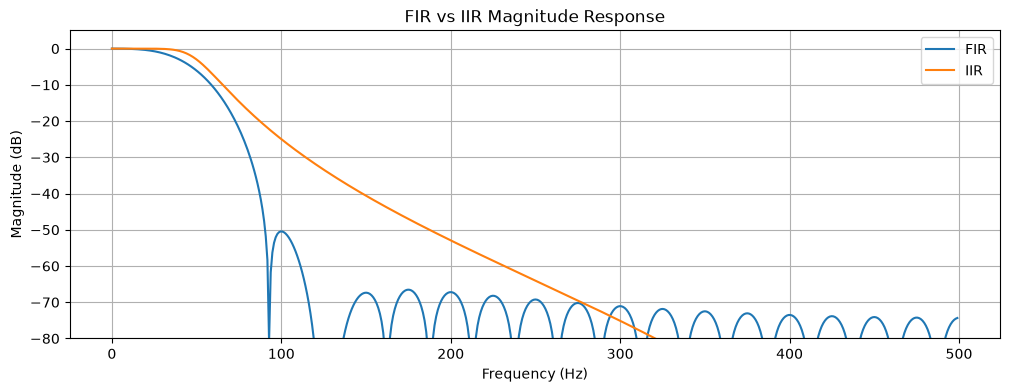

In [16]:
# compare magnitude responses
w_fir, H_fir = signal.freqz(b_fir, a_fir, fs=fs)
w_iir, H_iir = signal.freqz(b_iir, a_iir, fs=fs)

plt.figure(figsize=(12,4))

plt.plot(w_fir, 20*np.log10(np.abs(H_fir)))
plt.plot(w_iir, 20*np.log10(np.abs(H_iir)))

plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude (dB)")
plt.ylim(-80, 5)
plt.title("FIR vs IIR Magnitude Response")
plt.legend(["FIR", "IIR"])
plt.grid(True)
plt.show()

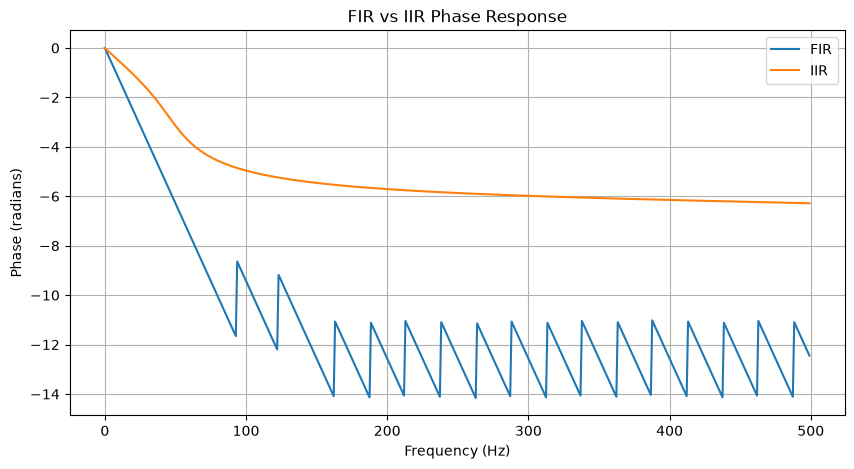

In [11]:
# Phase response

phase_fir = np.unwrap(np.angle(H_fir))
phase_iir = np.unwrap(np.angle(H_iir))

plt.figure(figsize=(10, 5))

plt.plot(w_fir, phase_fir)
plt.plot(w_iir, phase_iir)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Phase (radians)")
plt.title("FIR vs IIR Phase Response")
plt.legend(["FIR", "IIR"])
plt.grid(True)
plt.show()

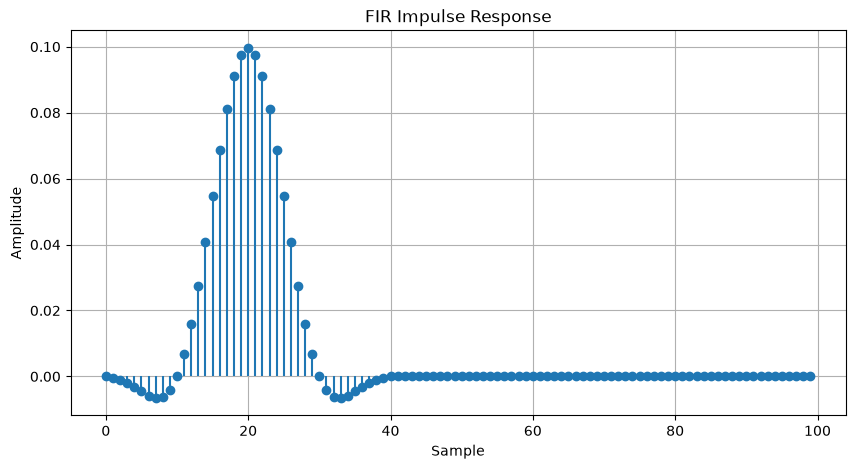

In [13]:
# Compare impulse responses

N=100
impulse = np.zeros(N)
impulse[0]= 1

h_fir = signal.lfilter(b_fir, a_fir, impulse)
h_iir = signal.lfilter(b_iir, a_iir, impulse)

plt.figure(figsize=(10, 5))

plt.stem(h_fir, linefmt='C0-', markerfmt='C0o', basefmt=' ')
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("FIR Impulse Response")
plt.grid(True)
plt.show()

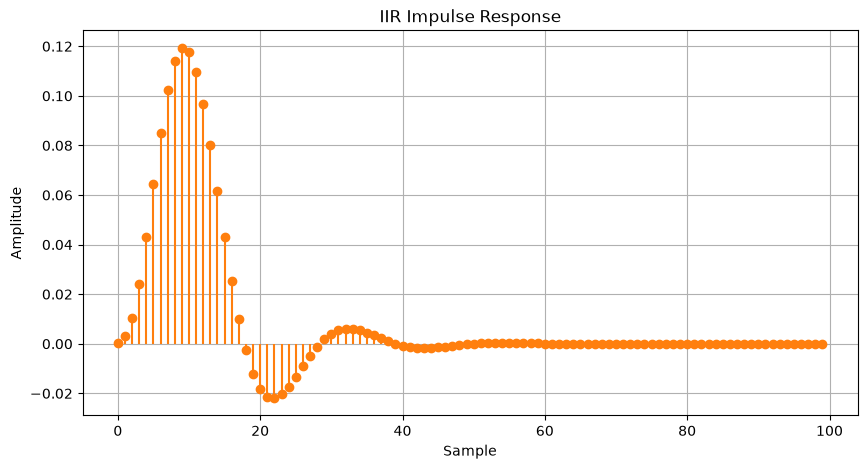

In [14]:
plt.figure(figsize=(10, 5))

plt.stem(h_iir, linefmt='C1-', markerfmt='C1o', basefmt=' ')
plt.xlabel("Sample")
plt.ylabel("Amplitude")
plt.title("IIR Impulse Response")
plt.grid(True)
plt.show()

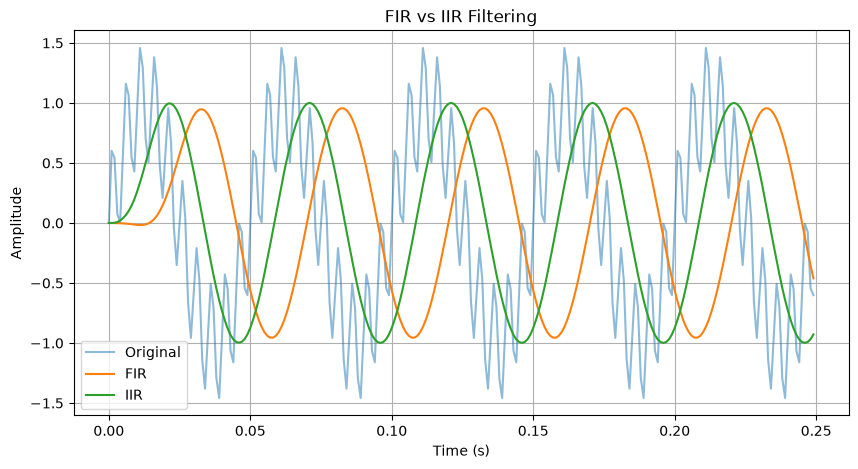

In [15]:
y_fir = signal.lfilter(b_fir, a_fir, x)
y_iir = signal.lfilter(b_iir, a_iir, x)
samples = int(0.25 * fs)

plt.figure(figsize=(10, 5))

plt.plot(t[:samples], x[:samples], alpha=0.5)
plt.plot(t[:samples], y_fir[:samples])
plt.plot(t[:samples], y_iir[:samples])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title("FIR vs IIR Filtering")
plt.legend(["Original", "FIR", "IIR"])
plt.grid(True)
plt.show()

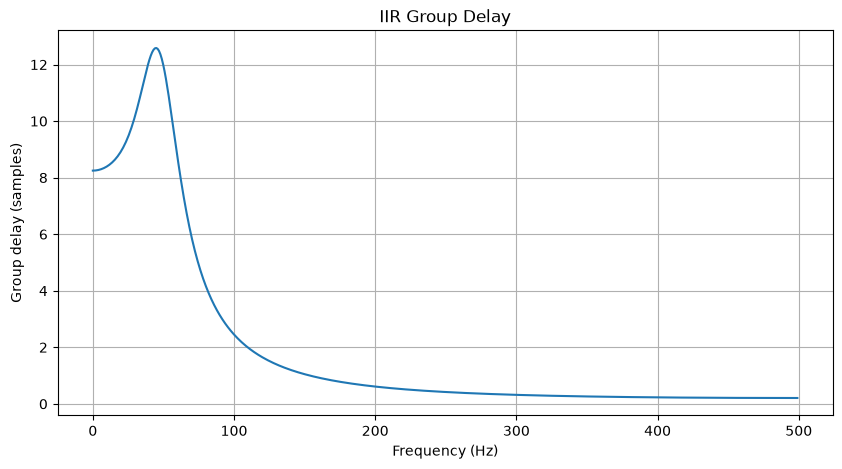

In [17]:
gd_w, gd_iir = signal.group_delay(
    (b_iir, a_iir),
    fs=fs
)

plt.figure(figsize=(10, 5))
plt.plot(gd_w, gd_iir)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Group delay (samples)")
plt.title("IIR Group Delay")
plt.grid(True)
plt.show()

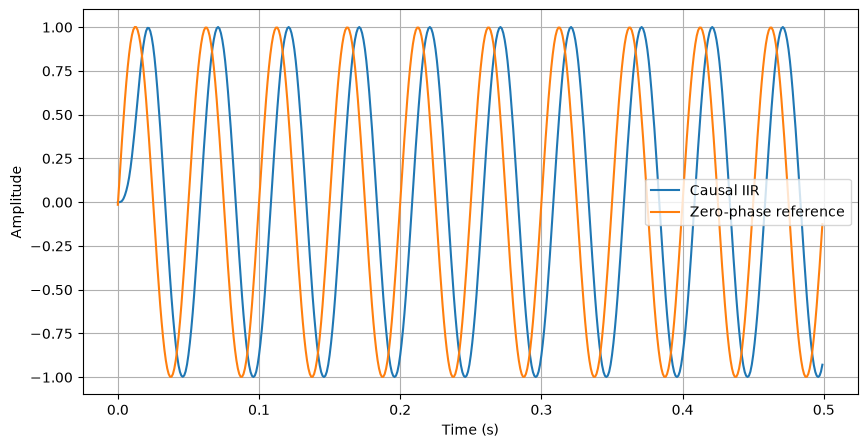

In [18]:
y_iir = signal.lfilter(b_iir, a_iir, x)
y_zero = signal.filtfilt(b_iir, a_iir, x)
plt.figure(figsize=(10, 5))

plt.plot(t[:500], y_iir[:500])
plt.plot(t[:500], y_zero[:500])

plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend(["Causal IIR", "Zero-phase reference"])
plt.grid(True)
plt.show()